# Notebook Python - Projet Machine Learning 

In [1]:
import numpy as np
import pandas as pd
import matplotlib as mlt
import sklearn as sk
import matplotlib.pyplot as plt
import seaborn as sns
import math

## Import des données et vérification du contenu  

In [2]:
#Importer les données 
path=""
health=pd.read_csv(path+"healthcare_synthetic_data.csv", sep=",", header=0)

#On vérifie le contenu
health.head()

,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar,Smoking_Status,Alcohol_Consumption,Physical_Activity_Level,Family_History,Stress_Level,Sleep_Hours,Heart_Disease_Risk
0,PID-00001,60,0,146.9,51.3,23.8,140,89,217,151,52,83,0,1,3,0,1,8,0
1,PID-00002,53,0,161.8,76.6,29.3,128,81,203,119,38,116,0,0,1,0,7,9,0
2,PID-00003,62,1,174.7,92.4,30.3,141,100,173,124,45,90,0,0,0,0,1,7,1
3,PID-00004,73,1,173.3,68.9,22.9,136,96,193,117,45,81,0,0,1,0,2,7,1
4,PID-00005,52,1,178.6,79.8,25.0,122,80,236,153,41,79,0,1,2,0,2,6,0


On regarde le type de chaque variable 

In [3]:
health.info() 

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               15000 non-null  str    
 1   Age                      15000 non-null  int64  
 2   Gender                   15000 non-null  int64  
 3   Height_cm                15000 non-null  float64
 4   Weight_kg                15000 non-null  float64
 5   BMI                      15000 non-null  float64
 6   Systolic_BP              15000 non-null  int64  
 7   Diastolic_BP             15000 non-null  int64  
 8   Cholesterol_Total        15000 non-null  int64  
 9   Cholesterol_LDL          15000 non-null  int64  
 10  Cholesterol_HDL          15000 non-null  int64  
 11  Fasting_Blood_Sugar      15000 non-null  int64  
 12  Smoking_Status           15000 non-null  int64  
 13  Alcohol_Consumption      15000 non-null  int64  
 14  Physical_Activity_Level  15000 no

On met le bon type pour chaque données (en particulier, on indique les variables qualitatives)

In [4]:
health['Patient_ID'] = pd.Categorical(health['Patient_ID'])
health['Gender'] = pd.Categorical(health['Gender'])
health['Smoking_Status'] = pd.Categorical(health['Smoking_Status'])
health['Alcohol_Consumption'] = pd.Categorical(health['Alcohol_Consumption'])
health['Physical_Activity_Level'] = pd.Categorical(health['Physical_Activity_Level'])
health['Family_History'] = pd.Categorical(health['Family_History'])
health['Stress_Level'] = pd.Categorical(health['Stress_Level'])
health['Sleep_Hours'] = pd.Categorical(health['Sleep_Hours'])
health['Heart_Disease_Risk'] = pd.Categorical(health['Heart_Disease_Risk'])

health.describe()

,Age,Height_cm,Weight_kg,BMI,Systolic_BP,Diastolic_BP,Cholesterol_Total,Cholesterol_LDL,Cholesterol_HDL,Fasting_Blood_Sugar
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,54.538133,165.336767,75.252573,27.446080,135.117667,90.541267,216.248000,140.355267,43.307867,99.670200
std,11.875294,9.186313,14.110559,4.134953,11.260634,8.443095,22.692222,17.914089,5.963153,15.261355
min,25.000000,138.500000,33.700000,14.500000,90.000000,60.000000,127.000000,70.000000,20.000000,60.000000
25%,46.000000,158.500000,65.200000,24.500000,127.000000,85.000000,201.000000,128.000000,39.000000,89.000000
50%,55.000000,164.700000,73.900000,27.200000,135.000000,91.000000,216.000000,140.000000,43.000000,99.000000
75%,63.000000,172.000000,83.900000,30.000000,143.000000,96.000000,231.000000,152.000000,47.000000,110.000000
max,85.000000,198.100000,150.100000,46.100000,182.000000,120.000000,303.000000,210.000000,68.000000,167.000000


## Modification des données 

### Transformation en Gaussienne 
on définit une fonction pour observer la distribution de nos variables quantitatives 

In [5]:
def plot_quantitative(df):
    # Sélectionner les colonnes numériques du DataFrame
    vars_num = df.select_dtypes(include=['number']).columns
    n_vars = len(vars_num)
    
    if n_vars == 0:
        print("Aucune variable numérique trouvée.")
        return

    # Calculer le nombre de lignes nécessaires pour 3 colonnes dans la grille 
    ncols = 3
    nrows = math.ceil(n_vars / ncols)

    # Créer la figure et les axes
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()  # Aplatir pour itérer facilement

    for i, col in enumerate(vars_num):
        # Création de l'histogramme + densité (kde)
        sns.histplot(df[col], kde=True, stat="density", 
                     color="grey", edgecolor="black",bins=30, 
                     line_kws={"color": "blue"}, ax=axes[i])
        
        axes[i].set_title(col)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Density")
        axes[i].grid(True, alpha=0.3)

    # Supprimer les graphiques vides si n_vars n'est pas un multiple de 3
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

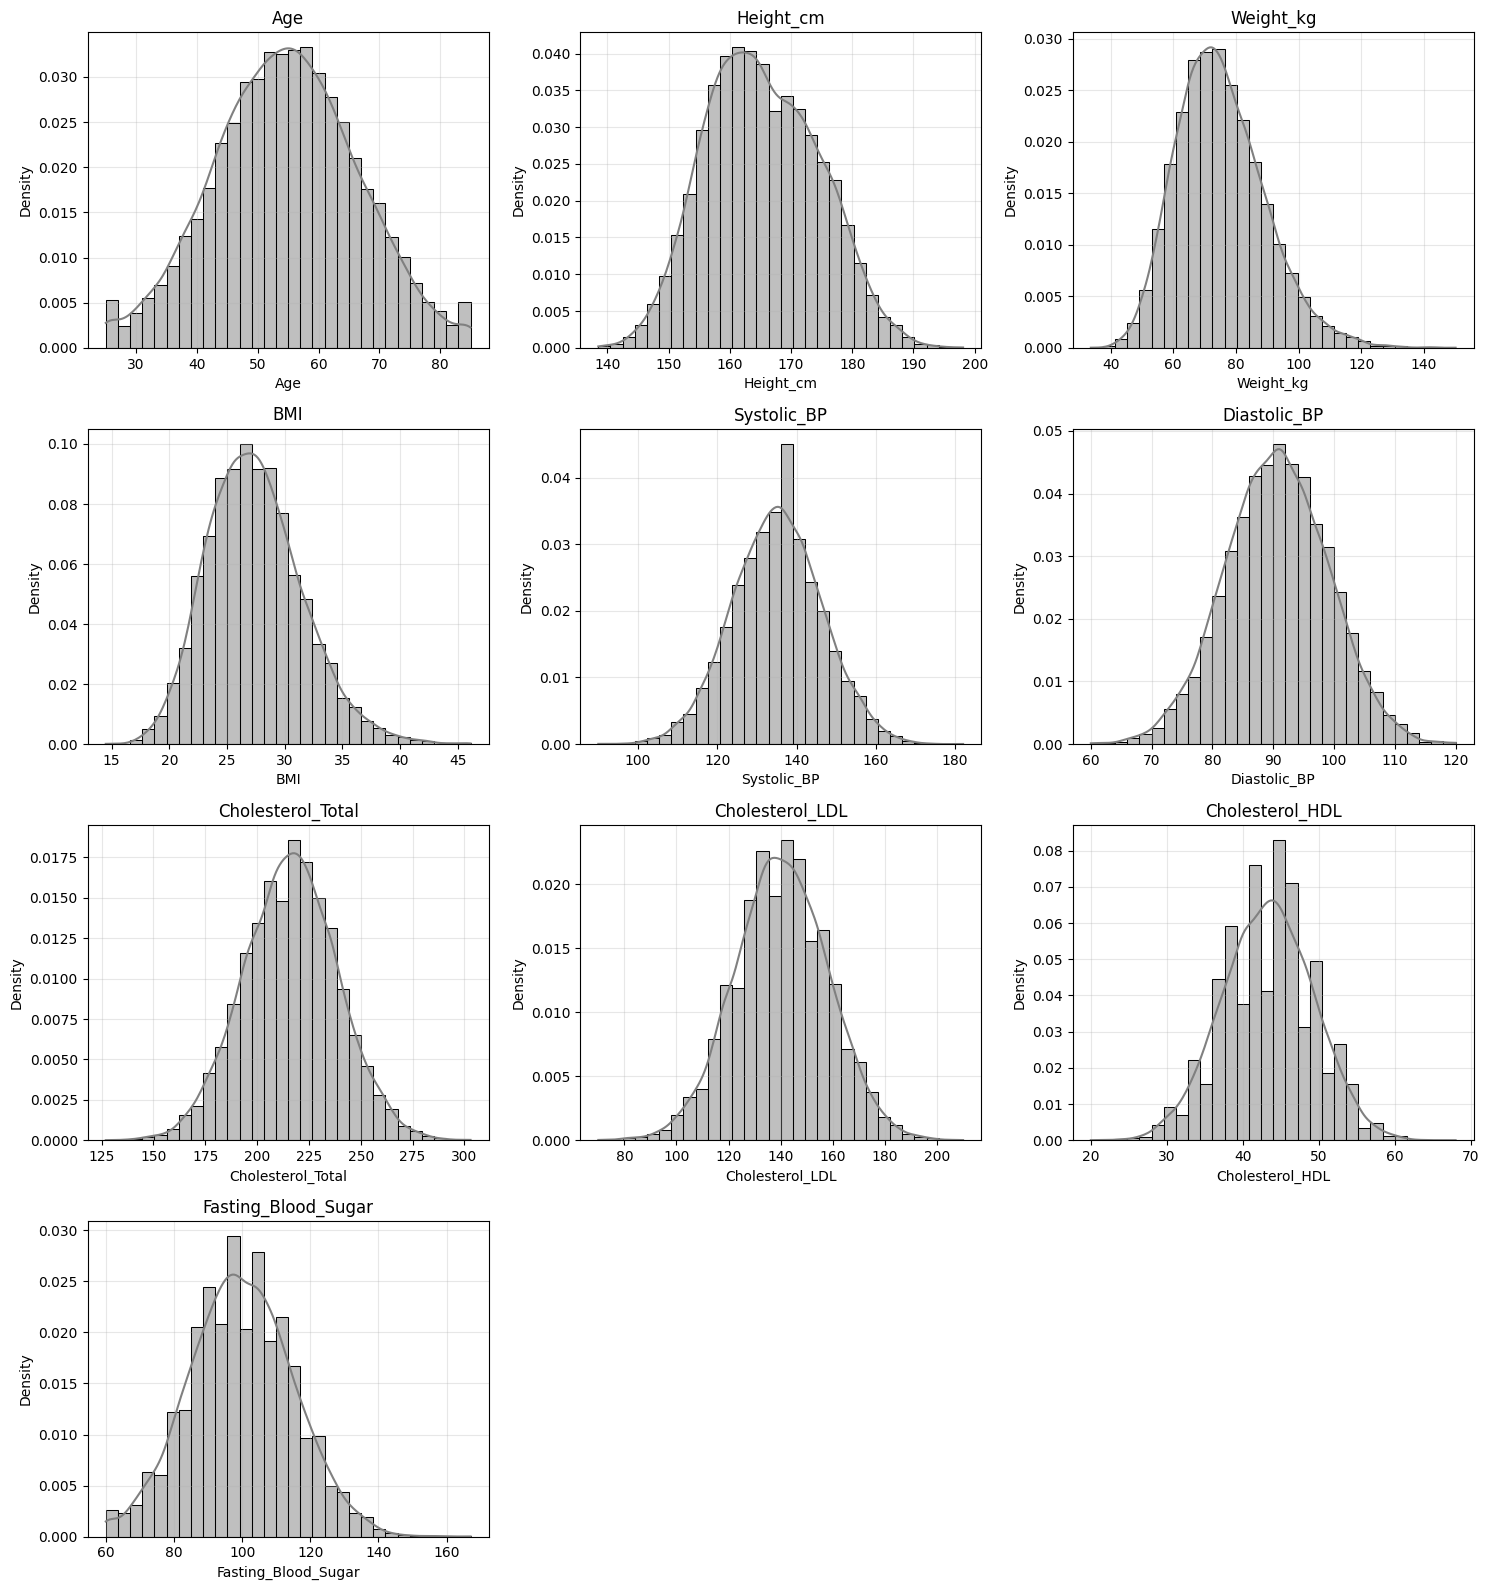

In [6]:
#on l'utilise sur notre dataset original 
plot_quantitative(health)

On transforme nos données pour avoir des distributions Gaussiennes (expliquer pourquoi). On trace les histogrammes de nos nouvelles variables

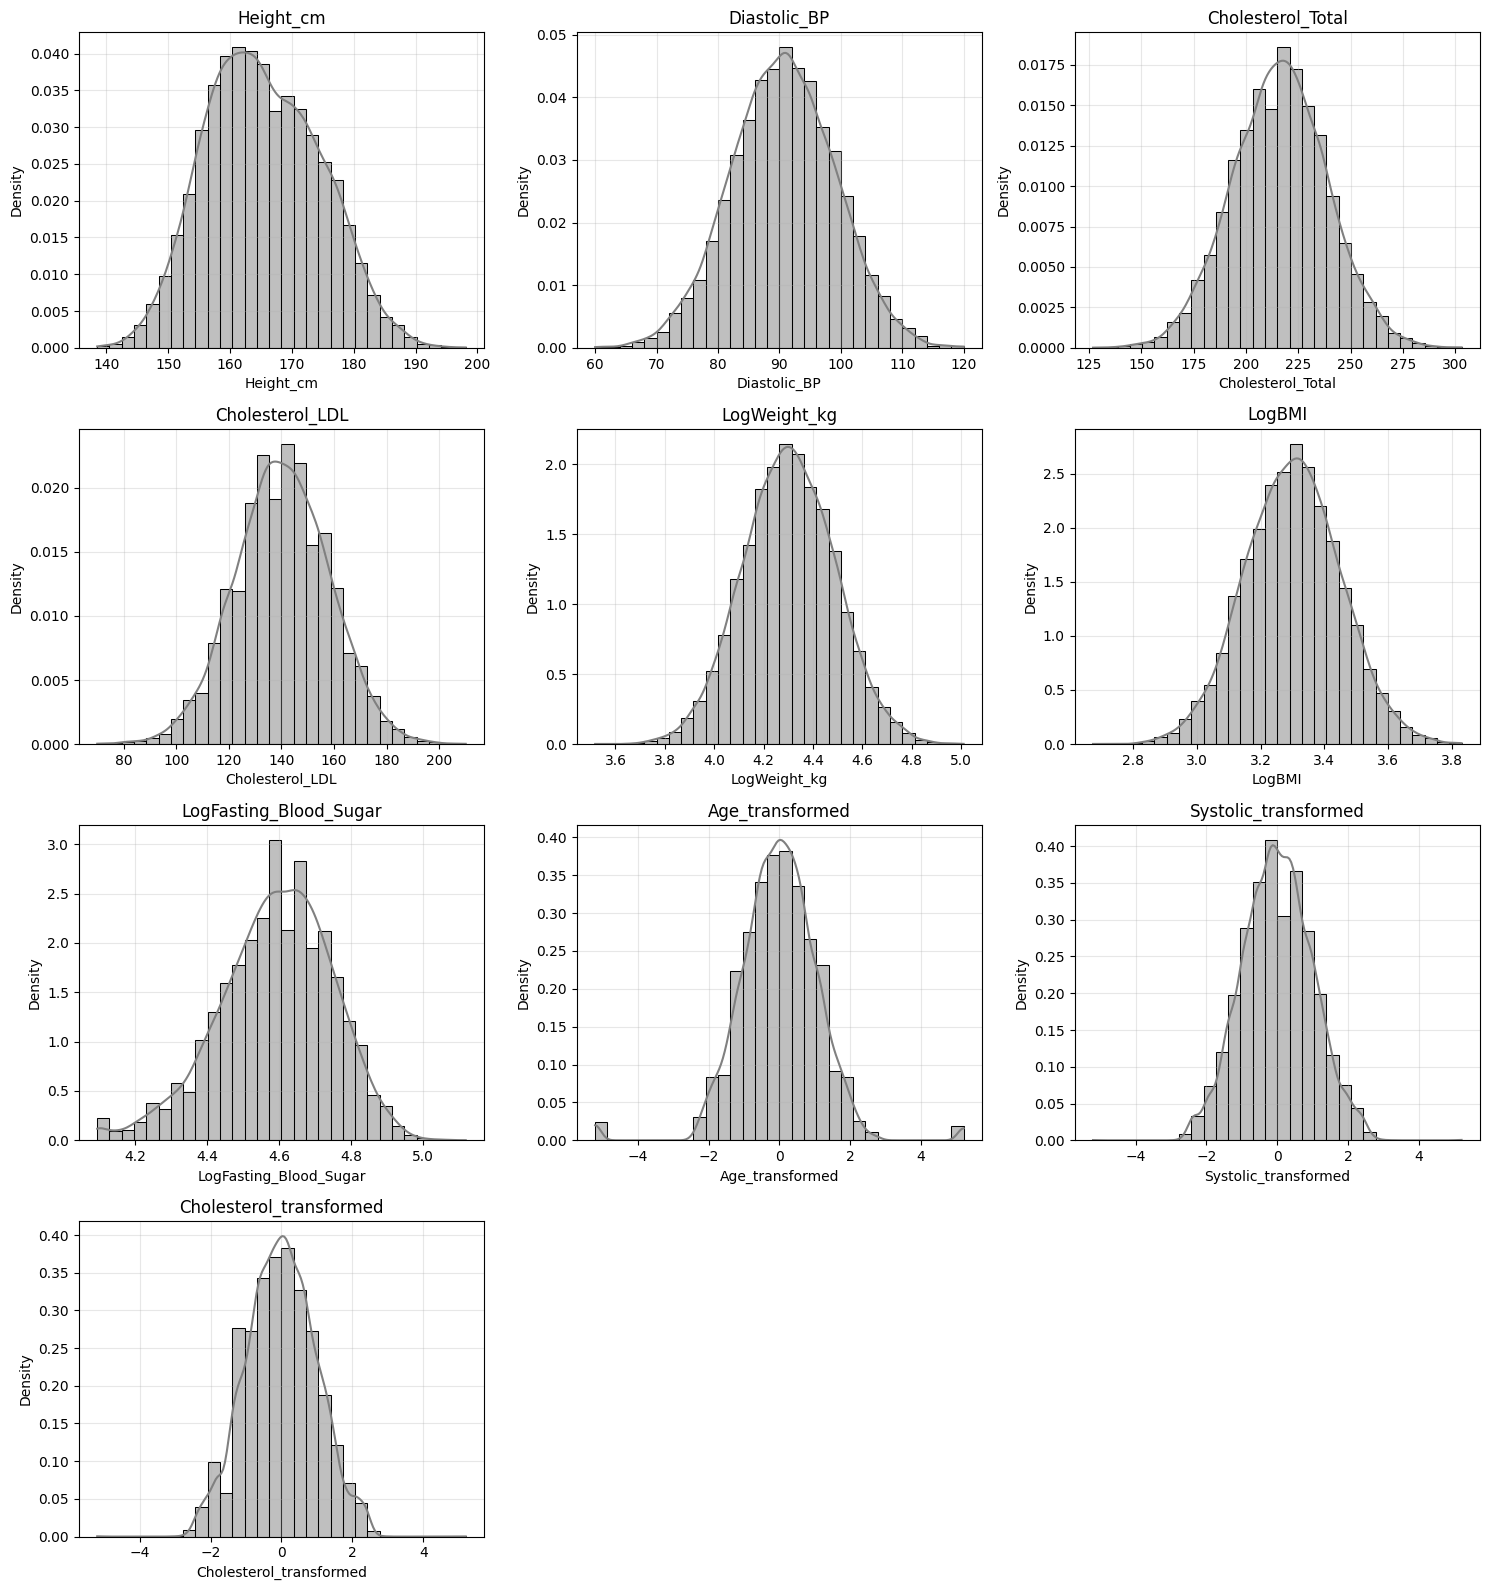

In [7]:
# on applique une transformation LOG sur les variables très asymétriques 
log_transformations = {
    "Weight_kg": "LogWeight_kg",
    "BMI": "LogBMI",
    "Fasting_Blood_Sugar": "LogFasting_Blood_Sugar"
}

#on applique une transformation QUANTILE sur les variables avec des outliers
# cette transformation tri les données et associe à chaque valeur un quantile de la distribution normale
qt_transformations = {
    "Age": "Age_transformed",
    "Systolic_BP": "Systolic_transformed",
    "Cholesterol_HDL": "Cholesterol_transformed"
}

# cette boucle nous permet de pouvoir relancer la cellule plusieurs fois sans erreur. Si la source n'existe plus, on ne fait rien
for old_col, new_col in log_transformations.items():
    if old_col in health.columns:
        health[new_col] = np.log(health[old_col])
        health = health.drop(columns=[old_col]) # On supprime l'originale tout de suite


from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal', n_quantiles=100)
#pareil pour la transformation quantile
for old_col, new_col in qt_transformations.items():
    if old_col in health.columns:
        health[new_col] = qt.fit_transform(health[[old_col]])
        health = health.drop(columns=[old_col])

# 4. Affichage
plot_quantitative(health)

On peut voir qu'il y a encore des défauts, on observe des "pics" ou des "trous" et des valeurs aberrantes. Cependant, ceci est lié à l'arrondi des données de santé, l'affichage... Les données sont assez gaussiennes pour notre utilisation. (je crois, à vérifier)

### Transformation des données pour l'apprentissage 

On commence par séparer les variables explicatives de la variable à expliquer 

In [8]:
#on définit la cible : le Heart_Disease_Risk, celle ci est binaire et indique si le patient est à risque de maladie cardiaque ou non
health_target = health['Heart_Disease_Risk']

health_features = health.drop(['Heart_Disease_Risk', 'Patient_ID'], axis=1)# Patient_ID est une variable catégorielle qui n'apporte pas d'information pour la prédiction

health_features = pd.get_dummies(health_features, columns=['Gender', 'Smoking_Status', 'Family_History', 'Alcohol_Consumption','Stress_Level','Sleep_Hours'], drop_first=True)



note : on a mit en "dummies" uniquement les variables binaires, les variables telles que Stress_level par exemple ne sont pas mises en dummies, car elles sont "ordonnées"  j'ai remis en fait, tests

(est ce que c'est bien?)
Moi ça me semble bien ! je rédigerai un petit truc pour justifier après 


On split le data set. En effet, nous souhaitons mettre en place une procédure permettant de séléctionner le meilleur modèle. On doit donc pouvoir tester chqaue modèle sur un dataset de test, afin de detecter par exemple l'over fitting
On justifie le choix de la taille de chaque ensemble d'entrainement ?


In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(health_features, health_target, test_size=0.2, train_size=0.8) # on renomme en X/y pour la lisibilité
print("la dimension de X_train est : ", np.shape(X_train))
print("la dimension de X_test est : ", np.shape(X_test))
print("la dimension de Y_train est : ", np.shape(Y_train))
print("la dimension de Y_test est : ", np.shape(Y_test))


la dimension de X_train est :  (12000, 31)
la dimension de X_test est :  (3000, 31)
la dimension de Y_train est :  (12000,)
la dimension de Y_test est :  (3000,)


On normalise les variables. (dire pourquoi)

In [10]:
from sklearn.preprocessing import StandardScaler  

scaler = StandardScaler()  
scaler.fit(X_train)  
Xs_train= scaler.transform(X_train)  
# Meme transformation sur le test -> on part du principe que les données de test suivent la même distribution que les données d'entraînement, on applique donc la même transformation
Xs_test= scaler.transform(X_test)

## Modèles linéaires 

blablalbla petite intro sur le modèle linéaire 

### Modèle linéaire sans pénalisation, sans séléction de variable 

#### Avec librarie sklearn

La variable qu'on cherche à prédire, "Heart_Disease_Risk" est binaire, on utilise donc une régréssion logistique 

Question= à quoi correspondent les itérations ?

In [11]:
from sklearn.linear_model import LogisticRegression

logReg_none = LogisticRegression(penalty=None, max_iter=10000) # on initialise le modèle, le max_iter est mis à 10000 pour être sûr que le modèle converge, on veut faire sans pénalité pour commencer.  
logReg_none.fit(Xs_train, Y_train)

c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

On observe les résultats, on regarde les performances sur le dataset de test

In [12]:
from sklearn.metrics import accuracy_score, classification_report

# Prédiction
Y_pred_lrn = logReg_none.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lrn):.2%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lrn))

Précision du modèle : 75.13%
              precision    recall  f1-score   support

           0       0.76      0.82      0.79      1705
           1       0.73      0.67      0.70      1295

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



On fait la matrice de confusions (c ça le nom ?)

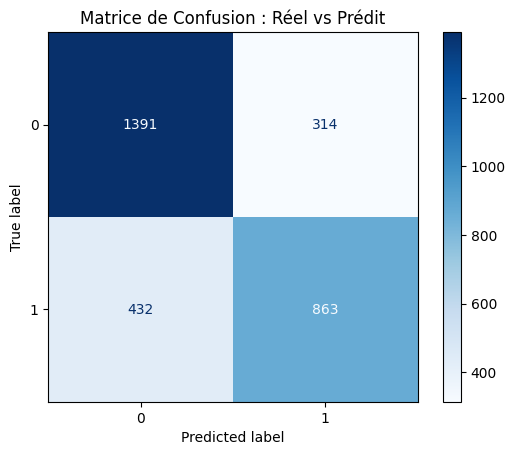

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lrn)

# L'afficher de manière élégante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_none.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion : Réel vs Prédit")
plt.show()


Dans ce cas, on prédit les risques de heart_disease : il est primordial de minimiser les faux négatifs

#### Avec librairie Statsmodels

Celle ci nous permet d'avoir des résultats plus détaillés. Nous pouvons analyser les p-valeurs et les poids des variables 

In [14]:
import statsmodels.api as sm

# Pour retrouver les noms dans le summary de statsmodels
X_train_df = pd.DataFrame(Xs_train, columns=health_features.columns)
X_train_df = sm.add_constant(X_train_df) # on ajoute un intercept pour que le modèle puisse apprendre une constante ( pas automatique dans la libraire)
regLog_stat = sm.Logit(Y_train.reset_index(drop=True), X_train_df).fit()
print(regLog_stat.summary())


Optimization terminated successfully.
         Current function value: 0.529576
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:     Heart_Disease_Risk   No. Observations:                12000
Model:                          Logit   Df Residuals:                    11968
Method:                           MLE   Df Model:                           31
Date:                Sat, 11 Apr 2026   Pseudo R-squ.:                  0.2271
Time:                        17:26:53   Log-Likelihood:                -6354.9
converged:                       True   LL-Null:                       -8222.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -0.3130      0.022    -14.330      0.000      -0.356   

### Modèle linéaire avec pénalisation LASSO

$$\widehat{\beta}_{\text{Lasso}} = \text{argmin}_{\beta \in \mathbb{R}^{p+1}} \left( \sum_{i=1}^{n} (Y_i - \sum_{j=0}^{p} X_i^{(j)}\beta_j)^2 + \lambda \sum_{j=1}^{p} |\beta_j| \right) \text{Avec } \lambda \text{ un paramètre à calibrer }$$

Cette pénalité ajoute une pénalité au modèle s'il utilise trop de variables ou des coefficients trop grand. Il élimine les variables inutiles, et évite l'overfitting

#### Avec la librarie sklearn 

On utilise la fonction *LogisticRegressionCV*, celle ci trouve le meilleur lamda par cross-validation

note : vérifier que L1 c lasso

In [15]:
from sklearn.linear_model import LogisticRegressionCV

# on fait une validation à cs=5 plis et on teste 20 valeurs de C différentes (inverse de lambda, le paramètre de régularisation)
logReg_lasso = LogisticRegressionCV(penalty='l1',solver='saga', max_iter=10000, cv=5, Cs=20) #L1= lasso. Saga doit être utilisé pour la pénalité L1 car le solveur par défaut (liblinear) ne supporte pas la pénalité L1 
logReg_lasso.fit(Xs_train, Y_train)

print(f"Meilleur paramètre C trouvé : {logReg_lasso.C_[0]}")

c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Proj

Meilleur paramètre C trouvé : 0.615848211066026


In [16]:
# Prédiction
Y_pred_lrl = logReg_lasso.predict(Xs_test)

# Affichage du score (Précision globale)
print(f"Précision du modèle : {accuracy_score(Y_test, Y_pred_lrl):.2%}")

# Détail des performances (Précision, Rappel par classe)
print(classification_report(Y_test, Y_pred_lrl))

Précision du modèle : 75.23%
              precision    recall  f1-score   support

           0       0.76      0.82      0.79      1705
           1       0.73      0.67      0.70      1295

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



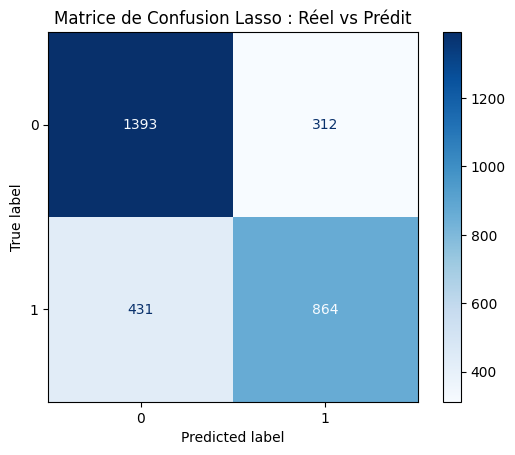

In [17]:
# Générer la matrice
cm = confusion_matrix(Y_test, Y_pred_lrl)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=logReg_lasso.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()

Le Lasso a éliminé 1 variables sur 31.
    Variable  Coefficient
0  Height_cm          0.0


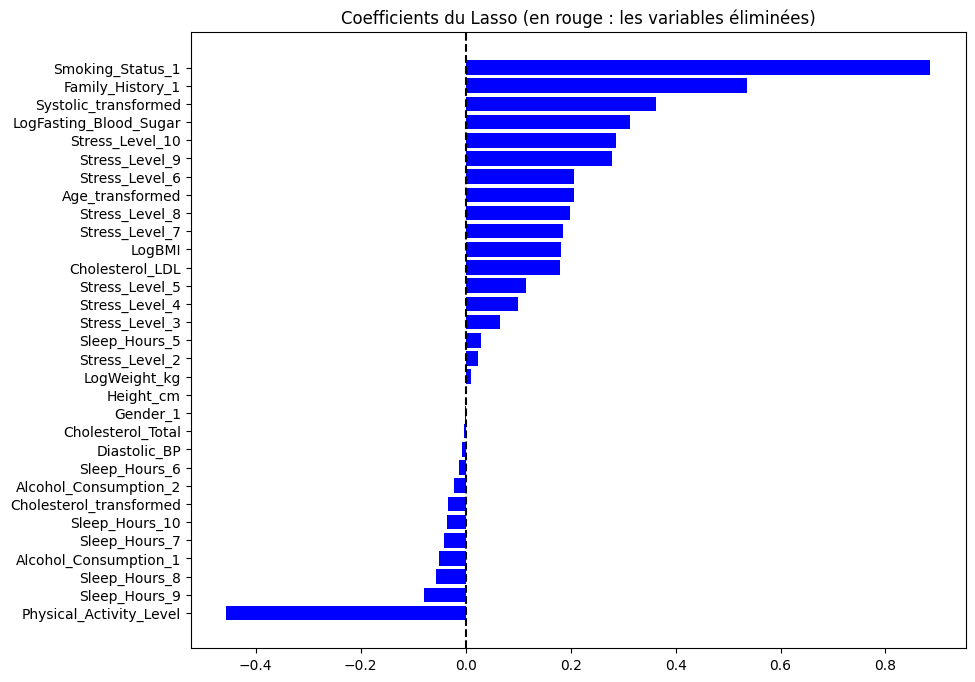

In [18]:
coeffs_df = pd.DataFrame({
    'Variable': health_features.columns, # nom des colonnes, pour l'analyse d'importance des variables
    'Coefficient': logReg_lasso.coef_[0] # .coef_[0] car pour une logistique binaire, c'est une liste de listes
})

variables_eliminees = coeffs_df[coeffs_df['Coefficient'] == 0]

print(f"Le Lasso a éliminé {len(variables_eliminees)} variables sur {len(health_features.columns)}.")
print(variables_eliminees)

coeffs_df = coeffs_df.sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
plt.barh(coeffs_df['Variable'], coeffs_df['Coefficient'], 
         color=['red' if c == 0 else 'blue' for c in coeffs_df['Coefficient']])
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Coefficients du Lasso (en rouge : les variables éliminées)")
plt.show()

Lorsqu'on ajoute une pénalisation, on "biaise" les coefficients pour les réduire. Les tests statistiques classiques ne marchent donc plus. Il n'est donc pas forcément pertinent d'utiliser Statsmodels

### Modèle linéaire avec pénalisation de Ridge 

$$\widehat{\beta} = \text{argmin}_{\widetilde{\beta} \in \mathbb{R}^{p+1}} \left( \| \mathbf{Y} - \widetilde{\mathbf{X}} \widetilde{\beta} \|^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \right) \text{Avec } \lambda \text{ à calibrer}$$

Contrairement à Ridge, cette pénalisation ne met pas les coefficients à 0, elle les réduit pour éviter l'overfitting. 

In [19]:
logReg_ridge = LogisticRegressionCV(penalty='l2', solver='lbfgs', max_iter=10000, cv=5, Cs=20)
logReg_ridge.fit(Xs_train, Y_train)
print(f"Meilleur paramètre C trouvé : {logReg_ridge.C_[0]}")

c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Proj

Meilleur paramètre C trouvé : 0.004832930238571752


In [20]:

y_logReg_ridge = logReg_ridge.predict(Xs_test)
print(classification_report(Y_test, y_logReg_ridge))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79      1705
           1       0.74      0.65      0.69      1295

    accuracy                           0.75      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.75      0.75      3000



Le Ridge a éliminé 0 variables sur 31.
Empty DataFrame
Columns: [Variable, Coefficient]
Index: []


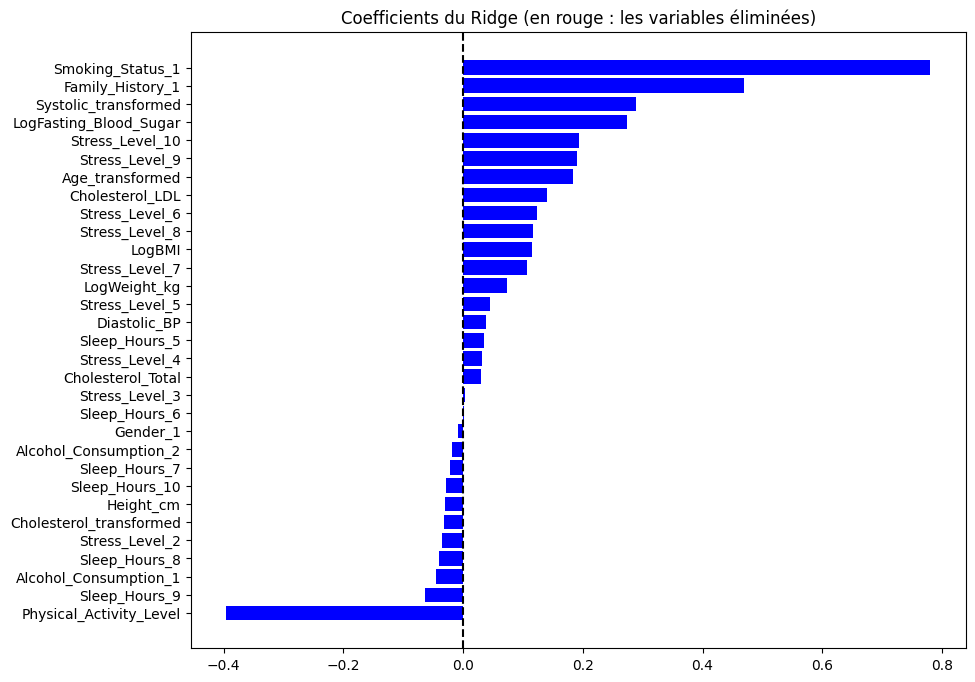

In [21]:
coeffs_df_ridge = pd.DataFrame({
    'Variable': health_features.columns, # nom des colonnes, pour l'analyse d'importance des variables
    'Coefficient': logReg_ridge.coef_[0] # .coef_[0] car pour une logistique binaire, c'est une liste de listes
})

variables_eliminees = coeffs_df_ridge[coeffs_df_ridge['Coefficient'] == 0]

print(f"Le Ridge a éliminé {len(variables_eliminees)} variables sur {len(health_features.columns)}.")
print(variables_eliminees)

coeffs_df_ridge = coeffs_df_ridge.sort_values(by='Coefficient')

plt.figure(figsize=(10, 8))
plt.barh(coeffs_df_ridge['Variable'], coeffs_df_ridge['Coefficient'], 
         color=['red' if c == 0 else 'blue' for c in coeffs_df_ridge['Coefficient']])
plt.axvline(x=0, color='black', linestyle='--')
plt.title("Coefficients du Ridge (en rouge : les variables éliminées)")
plt.show()

### Conclusion 

| Métrique / Modèle | Sans pénalisation | Lasso (L1) | Ridge (L2) |
| :--- | :---: | :---: | :---: |
| **Paramètre C** | X | 11.28 | 0.66 |
| **Accuracy** | 0.74 | 0.74 | 0.74 |
| **Précision (Classe 0)** |0.75 |0.75 |0.75 |
| **Précision (Classe 1)** | 0.72| 0.72|0.72 |
| **Recall (Classe 0)** |0.8 | 0.8| 0.8|
| **Recall (Classe 1)** |0.66 |0.66 |0.66 |
| **Variables éliminées** | 0 | 0 | 0 |

On peut voir que les résultats sont identiques pour toutes les méthodes, c'està dire que malgré la pénalisation, le modèle de régréssion logistique classique a été choisi. Cependant, nous pouvons voir dans la sortie de *Statsmodels* que beaucoup de variables ont des p-valeurs très faible, ce qui semble indiquer que nous pouvons simplifier le modèle. Nous pourrions forcer un C très petit ou utiliser une méthode de séléction de variable. C'est ce que nous allons faire. 

note : est ce que j'aurai du faire directement avec GridSearch? 

### Modèles linéaire avec séléction de variable BIC 

Malheureusement, il n'y a pas de fonction toute prête (est ce que c'est too much de faire ça et il faut plutot jouer sur le paramètre C pour faire baisser le nombre de variables ?)

In [22]:
def forward_selection_bic(X, y): # avec X le dataFramme pandas qu'on a crée 
    best_features = []
    remaining_features = list(X.columns)
    print(remaining_features)
    current_bic = float('inf')
    
    while remaining_features: # tant qu'il reste des variables à tester
        candidates_scores = [] # liste pour stocker les scores BIC de chaque variable candidate
        for candidate in remaining_features: # on boucle sur les variables restantes pour tester leur ajout au modèle
            features_to_test = best_features + [candidate] # on teste le modèle avec les variables déjà retenues + la variable candidate
            X_const = sm.add_constant(X[features_to_test], has_constant='add') # on ajoute aussi l'intercept pour que le modèle puisse apprendre une constante ( pas automatique dans la libraire)
            
            try:
                model = sm.Logit(y.reset_index(drop=True), X_const).fit(disp=0) # on fait le modèle avec la variable candidate 
                candidates_scores.append((model.bic, candidate)) # on met le score BIC et la variable candidate dans la liste
            except:
                continue # si erreur, on ne fait
                
        if not candidates_scores: 
            break
            
        candidates_scores.sort() # Tri pour avoir le score BIC le plus petit au début
        best_new_bic, best_candidate = candidates_scores[0] # on prend la variable candidate qui a le meilleur score BIC (le plus petit)
        
        if best_new_bic < current_bic: # Si le meilleur BIC trouvé est plus petit que l'actuel, on valide la variable
            remaining_features.remove(best_candidate) # on retire la variable candidate des variables restantes à tester
            best_features.append(best_candidate) # on ajoute la variable candidate à la liste des variables retenues
            current_bic = best_new_bic # on met à jour le BIC actuel avec le meilleur BIC trouvé
            print(f"Ajouté : {best_candidate} -> Nouveau BIC : {current_bic:.2f}")
        else:
            # L'ajout d'une variable supplémentaire augmente le BIC (le modèle devient trop complexe), on s'arrête
            print("L'ajout de nouvelles variables n'améliore plus le BIC. Fin.")
            break
            
    print(f"\nVariables finales retenues par le BIC : {best_features}")
    return best_features


In [23]:
X_train_df = pd.DataFrame(Xs_train, columns=health_features.columns)
variables_optimales = forward_selection_bic(X_train_df, Y_train)
print("nombres de variables retenues : ", len(variables_optimales), " sur ", len(health_features.columns))

['Height_cm', 'Diastolic_BP', 'Cholesterol_Total', 'Cholesterol_LDL', 'Physical_Activity_Level', 'LogWeight_kg', 'LogBMI', 'LogFasting_Blood_Sugar', 'Age_transformed', 'Systolic_transformed', 'Cholesterol_transformed', 'Gender_1', 'Smoking_Status_1', 'Family_History_1', 'Alcohol_Consumption_1', 'Alcohol_Consumption_2', 'Stress_Level_2', 'Stress_Level_3', 'Stress_Level_4', 'Stress_Level_5', 'Stress_Level_6', 'Stress_Level_7', 'Stress_Level_8', 'Stress_Level_9', 'Stress_Level_10', 'Sleep_Hours_5', 'Sleep_Hours_6', 'Sleep_Hours_7', 'Sleep_Hours_8', 'Sleep_Hours_9', 'Sleep_Hours_10']
Ajouté : Smoking_Status_1 -> Nouveau BIC : 15021.68
Ajouté : Family_History_1 -> Nouveau BIC : 14480.24
Ajouté : Systolic_transformed -> Nouveau BIC : 13937.16
Ajouté : Physical_Activity_Level -> Nouveau BIC : 13537.73
Ajouté : LogFasting_Blood_Sugar -> Nouveau BIC : 13271.65
Ajouté : Cholesterol_LDL -> Nouveau BIC : 13144.12
Ajouté : LogBMI -> Nouveau BIC : 13094.97
Ajouté : Age_transformed -> Nouveau BIC : 1

On modifie notre DB pour séléctionner seulement ces variables, et on refait notre modèle. 

In [24]:
Xs_BIC=X_train_df[variables_optimales] # on garde uniquement les variables retenues par le BIC pour l'entraînement du modèle final
logReg_BIC = LogisticRegression(penalty=None, max_iter=10000)
logReg_BIC.fit(Xs_BIC, Y_train) 

c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [25]:
X_test_df = pd.DataFrame(Xs_test, columns=health_features.columns)
Xs_test_BIC = X_test_df[variables_optimales]
y_pred_BIC = logReg_BIC.predict(Xs_test_BIC)
print(classification_report(Y_test, y_pred_BIC))
print(f"Accuracy globale : {accuracy_score(Y_test, y_pred_BIC):.2f}")


              precision    recall  f1-score   support

           0       0.76      0.82      0.79      1705
           1       0.74      0.66      0.70      1295

    accuracy                           0.76      3000
   macro avg       0.75      0.74      0.75      3000
weighted avg       0.75      0.76      0.75      3000

Accuracy globale : 0.76


toujours la même je vais devenir folle. Comment on a enlevé la moitié des variables et rien ne change ??? pk on les avait pas enlevé avant alors ???

### Conclusion 
fait par gemini à modifier 

1-Stabilité des performances : "L'application des pénalités L1, L2 et la sélection BIC montrent une convergence vers une accuracy de 0.74, ce qui suggère que le modèle a atteint sa capacité prédictive maximale pour une approche linéaire."

2-Interprétation du BIC : "Le modèle BIC est à privilégier car il offre la même performance (0.74) avec une structure plus simple, limitant ainsi les risques d'overfitting sur de nouvelles données."

3-Analyse des erreurs : Regarde si ce sont les mêmes individus qui sont mal classés par tous les modèles. Si oui, c'est que ces individus sont des "atypiques" que tes variables actuelles ne peuvent pas expliquer1

## SRM / SVM 
*linear support vector machine*

EVITER DE RELANCER CE QU4IL Y A EN DESSOUS? PREND 100 ANS 

In [26]:
from sklearn.svm import SVC # code prit du TP Ozonne 
from sklearn.model_selection import GridSearchCV

param=[{"C":[0.4,0.6,1,1.4]}]
svm= GridSearchCV(SVC(),param,cv=10,n_jobs=-1)
svmOpt=svm.fit(Xs_train, Y_train)
print("Meilleur score = %f, Meilleur paramètre = %s" % (1. - svmOpt.best_score_,svmOpt.best_params_))

Meilleur score = 0.275667, Meilleur paramètre = {'C': 0.4}


In [27]:
# erreur de prévision sur le test
print(1-svmOpt.score(Xs_test,Y_test))
print("accuracy : ", svmOpt.score(Xs_test,Y_test))

0.258
accuracy :  0.742


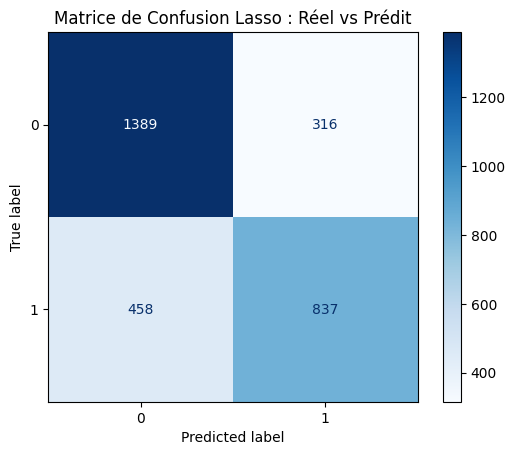

              precision    recall  f1-score   support

           0       0.75      0.81      0.78      1705
           1       0.73      0.65      0.68      1295

    accuracy                           0.74      3000
   macro avg       0.74      0.73      0.73      3000
weighted avg       0.74      0.74      0.74      3000



In [28]:
# prévision de l'échantillon test
y_chap = svmOpt.predict(Xs_test)
# matrice de confusion
cm = confusion_matrix(Y_test, y_chap)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=svmOpt.classes_)
disp.plot(cmap=plt.cm.Blues)

plt.title("Matrice de Confusion Lasso : Réel vs Prédit")
plt.show()

print (classification_report(Y_test, y_chap))

Bah c - bien ? Nul 

on peut faire avec differents noyaux ?

en 1000D, on ne peut pas faire les graphiques de séparation de petits points :()

# Comparaison des modèles - Courbes ROC
Dans cette partie, nous évaluons la performance des modèles de classification à l’aide de la courbe ROC, qui permet d’analyser sa capacité à distinguer correctement les observations positives et négatives. Cette approche nous permet également de comparer la qualité de différents modèles ou configurations en observant leur comportement pour différents seuils de décision. (à modif c'est chatos)

In [29]:
from sklearn.metrics import roc_curve

# On calcule les probabilités de prédiction pour chaque modèle
proba_logReg_none = logReg_none.predict_proba(X_test)[:,1]
proba_logReg_lasso = logReg_lasso.predict_proba(X_test)[:,1]
proba_logReg_ridge = logReg_ridge.predict_proba(X_test)[:,1]
proba_logReg_BIC = logReg_BIC.predict_proba(Xs_test_BIC)[:,1]

 # pour SVM, on utilise decision_function qui donne une mesure de la distance à la frontière de décision, plus c'est grand, plus le modèle est confiant que c'est la classe positive
proba_svmOpt = svmOpt.decision_function(Xs_test)


fpr_logReg_none, tpr_logReg_none, _ = roc_curve(Y_test, proba_logReg_none)
fpr_logReg_lasso, tpr_logReg_lasso, _ = roc_curve(Y_test, proba_logReg_lasso)
fpr_logReg_ridge, tpr_logReg_ridge, _ = roc_curve(Y_test, proba_logReg_ridge)
fpr_logReg_BIC, tpr_logReg_BIC, _ = roc_curve(Y_test, proba_logReg_BIC)
fpr_svmOpt, tpr_svmOpt, _ = roc_curve(Y_test, proba_svmOpt)
 

c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(
c:\Users\33670\OneDrive - INSA Toulouse\Documents\DOCUMENTS\Etudes\DD_INSA_SCPO\4A\Projet_ML\Projet_mlbbl_2\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegressionCV was fitted without feature names
  warnings.warn(


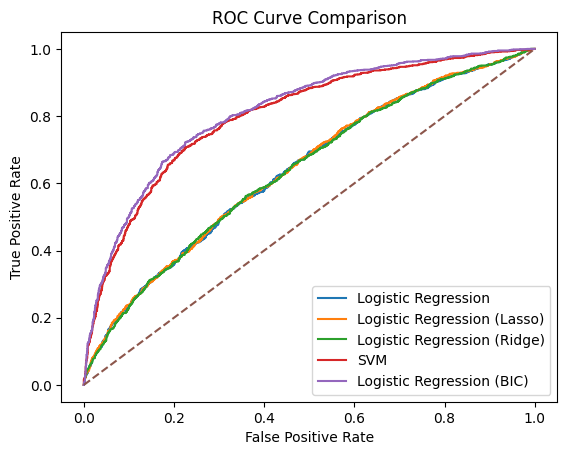

In [30]:
#On trace maintenant les courbes ROC
import matplotlib.pyplot as plt

plt.plot(fpr_logReg_none, tpr_logReg_none, label="Logistic Regression")
plt.plot(fpr_logReg_lasso, tpr_logReg_lasso, label="Logistic Regression (Lasso)")
plt.plot(fpr_logReg_ridge, tpr_logReg_ridge, label="Logistic Regression (Ridge)")
plt.plot(fpr_svmOpt, tpr_svmOpt, label="SVM")
plt.plot(fpr_logReg_BIC, tpr_logReg_BIC, label="Logistic Regression (BIC)")
plt.plot([0,1],[0,1], linestyle="--")  # modèle aléatoire

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()